In [ ]:
#import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
#load dataset
df=pd.read_csv('/content/score.csv')
print('DataSet Loaded Succaessfully')


DataSet Loaded Succaessfully


In [ ]:
#display 5 rows
df.head()

,Hours,Scores
0,2.5,21
1,5.1,47
2,3.2,27
3,8.5,75
4,3.5,30


In [ ]:
#Structure
df.shape

(25, 2)

In [ ]:
#Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Hours   25 non-null     float64
 1   Scores  25 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 532.0 bytes


In [ ]:
categorical_cols = df.select_dtypes(include=['object'])

print(categorical_cols.columns)

Index([], dtype='object')


In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64'])

print(numerical_cols.columns)

Index(['Hours', 'Scores'], dtype='object')


In [ ]:
df.tail()

,Hours,Scores
20,2.7,30
21,4.8,54
22,3.8,35
23,6.9,76
24,7.8,86


In [ ]:
df.describe()

,Hours,Scores
count,25.000000,25.000000
mean,5.012000,51.480000
std,2.525094,25.286887
min,1.100000,17.000000
25%,2.700000,30.000000
50%,4.800000,47.000000
75%,7.400000,75.000000
max,9.200000,95.000000


In [ ]:
#detect missing values
df.isnull().sum()

,0
Hours,0
Scores,0


In [ ]:
#covert Radio to the nearestlower integer by removing decimal values
df['Scores']=df['Scores'].apply(np.floor)
df

,Hours,Scores
0,2.5,21.0
1,5.1,47.0
2,3.2,27.0
3,8.5,75.0
4,3.5,30.0
5,1.5,20.0
6,9.2,88.0
7,5.5,60.0
8,8.3,81.0
9,2.7,25.0


In [ ]:
# Independent Variable (Feature)
x=df[['Hours']]
x

,Hours
0,2.5
1,5.1
2,3.2
3,8.5
4,3.5
5,1.5
6,9.2
7,5.5
8,8.3
9,2.7


In [ ]:
#dependent variable salary
y=df['Scores']
y

,Scores
0,21.0
1,47.0
2,27.0
3,75.0
4,30.0
5,20.0
6,88.0
7,60.0
8,81.0
9,25.0


In [ ]:
#split the dataset into training and testing
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
#create a model
model=LinearRegression()

In [ ]:
#train the model
model.fit(x_train, y_train)
print("Model Trained")

Model Trained


In [ ]:
#Generate predictions for training and testing datasets using the trained model
y_pred_train=model.predict(x_train)
y_pred_test=model.predict(x_test)
print("Predictions generated for both training and testing datasets")

Predictions generated for both training and testing datasets


In [ ]:
# Evaluate model performance on training data using MAE, MSE, RMSE, and R2 score
mae = mean_absolute_error(y_train, y_pred_train)
mse = mean_squared_error(y_train, y_pred_train)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred_train)
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root MSE (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 5.221357478352559
Mean Squared Error (MSE): 31.454835527366846
Root MSE (RMSE): 5.608461065868858
R2 Score: 0.9491209376364416


In [ ]:
# Evaluate model performance on test data using MAE, MSE, RMSE, and R2 score
mae_test = mean_absolute_error(y_test, y_pred_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_test)
print("Mean Absolute Error (MAE) on test data:", mae_test)
print("Mean Squared Error (MSE) on test data:", mse_test)
print("Root MSE (RMSE) on test data:", rmse_test)
print("R2 Score on test data:", r2_test)

Mean Absolute Error (MAE) on test data: 3.9207511902099244
Mean Squared Error (MSE) on test data: 18.943211722315272
Root MSE (RMSE) on test data: 4.352380006653288
R2 Score on test data: 0.9678055545167994


In [ ]:
#slope
model.coef_

array([9.68207815])

In [ ]:
#slope
model.coef_
#intercept
model.intercept_

np.float64(2.826892353899737)

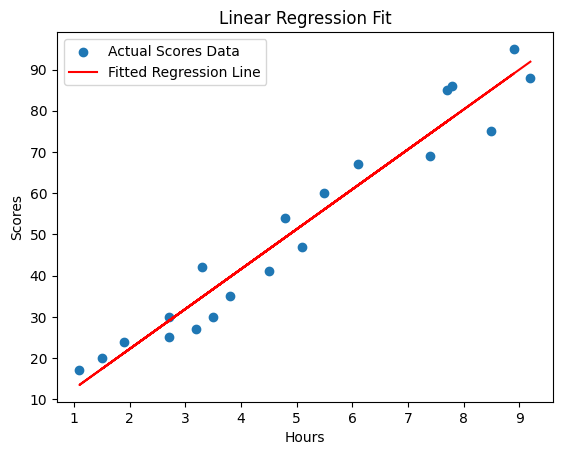

In [ ]:
# Plot actual training data points and the fitted linear regression line for visualization
plt.scatter(x_train['Hours'], y_train, label='Actual Scores Data')
plt.plot(x_train['Hours'], y_pred_train, color='red', label='Fitted Regression Line')
plt.xlabel('Hours'); plt.ylabel('Scores')
plt.title('Linear Regression Fit')
plt.legend(); plt.show()